/var/folders/97/8bx4_dmx3038pm1qrblmtrl80000gn/T/ipykernel_62373/1041583409.py:10: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df_true = pd.read_csv(true_path, parse_dates=[["date", "time"]])


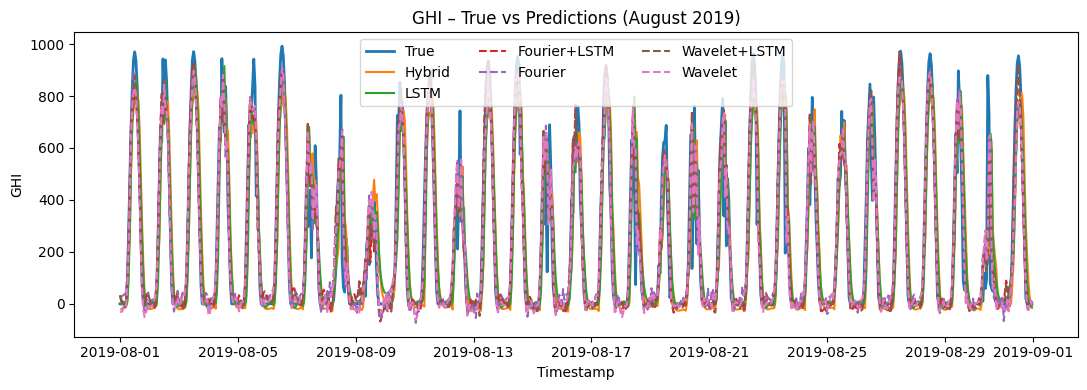

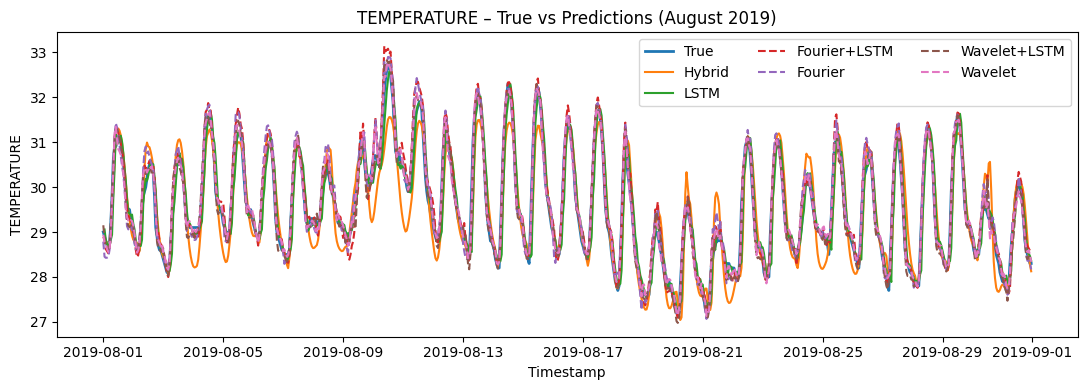

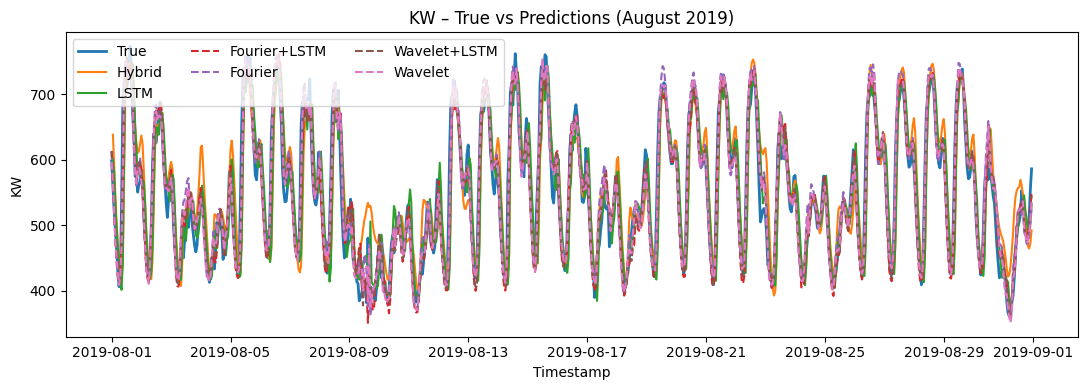

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# base directory (adjust if needed)
base = Path("/Users/rr/Documents/Diajeng/TA/program/progress_ta/dataset/dataset_lstm_hybrid")

# ---------- 1. Load TRUE values ----------
true_path = base / "dataset_agustus.csv"
df_true = pd.read_csv(true_path, parse_dates=[["date", "time"]])
df_true.rename(columns={"date_time": "timestamp"}, inplace=True)
df_true["timestamp"] = pd.to_datetime(df_true["timestamp"])

# Keep only August rows (redundant but safe)
df_true = df_true[df_true["timestamp"].dt.month == 8]

# ---------- 2. Helper to load single-col prediction --------
def load_pred(path, pred_col_name):
    df = pd.read_csv(path, parse_dates=["timestamp"])
    df = df[["timestamp", pred_col_name]].copy()
    return df

# ---------- 3. Collect predictions for each target ----------
targets = {
    "GHI": {
        "Hybrid": base / "hybrid_pred_vs_true_ghi_august.csv",
        "LSTM":   base / "lstm_pred_vs_true_ghi_august.csv",
    },
    "TEMPERATURE": {
        "Hybrid": base / "hybrid_pred_vs_true_temperature_august.csv",
        "LSTM":   base / "lstm_vs_true_temperature_august.csv",
    },
    "KW": {
        "Hybrid": base / "hybrid_pred_vs_true_kw_august.csv",
        "LSTM":   base / "lstm_pred_vs_true_kw_august.csv",
    }
}

# Fourier / wavelet MS files
ms_files = {
    "Fourier+LSTM": base / "1hour_fourier_withlstm_MS.csv",
    "Fourier":      base / "1hour_fourier_withoutlstm_MS.csv",
    "Wavelet+LSTM": base / "1hour_wavelets_withlstm_MS.csv",
    "Wavelet":      base / "1hour_wavelets_withoutlstm_MS.csv",
}

# Load MS dataframe (datetime col)
dfs_ms = {}
for name, path in ms_files.items():
    df = pd.read_csv(path, parse_dates=["datetime"])
    df.rename(columns={"datetime": "timestamp", "temperature": "TEMPERATURE"}, inplace=True)
    dfs_ms[name] = df[["timestamp", "ghi", "TEMPERATURE", "kw"]].copy()
    dfs_ms[name].rename(columns={"ghi": "GHI", "kw": "KW"}, inplace=True)

# ---------- 4. Plot per target ----------
for tgt, file_dict in targets.items():
    plt.figure(figsize=(11,4))
    
    # True line
    plt.plot(df_true["timestamp"], df_true[f"{tgt}_TRUE"], label="True", linewidth=2)
    
    # LSTM/Hybrid files
    for model_name, path in file_dict.items():
        pred_col = f"{tgt}_pred" if "pred" in pd.read_csv(path, nrows=0).columns[-1] else f"{tgt}_pred"
        df_pred = load_pred(path, pred_col)
        plt.plot(df_pred["timestamp"], df_pred[pred_col], label=model_name)
    
    # MS predictions
    for ms_name, df_ms in dfs_ms.items():
        plt.plot(df_ms["timestamp"], df_ms[tgt], label=ms_name, linestyle="--")
    
    plt.title(f"{tgt} – True vs Predictions (August 2019)")
    plt.xlabel("Timestamp")
    plt.ylabel(tgt)
    plt.legend(ncol=3)
    plt.tight_layout()
    plt.show()


/var/folders/97/8bx4_dmx3038pm1qrblmtrl80000gn/T/ipykernel_62373/4152024387.py:9: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  true_df = pd.read_csv(base / "dataset_agustus.csv", parse_dates=[["date", "time"]])


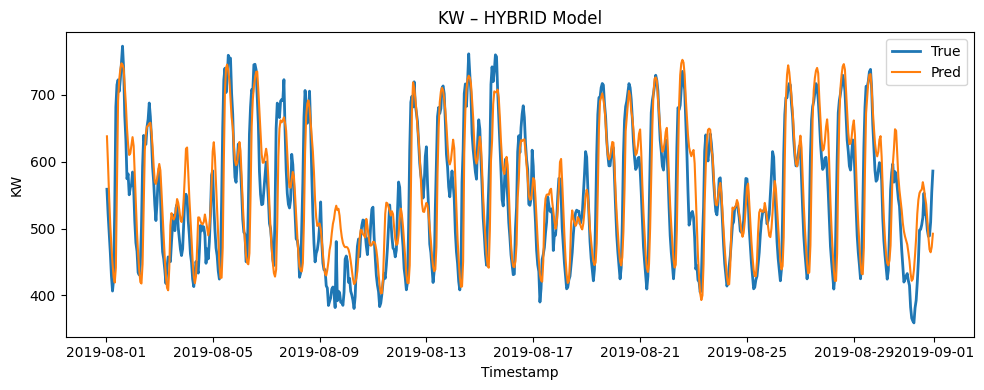

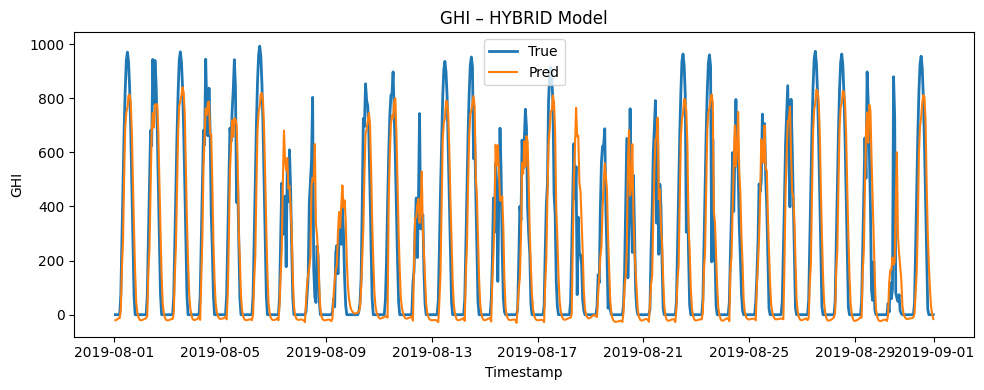

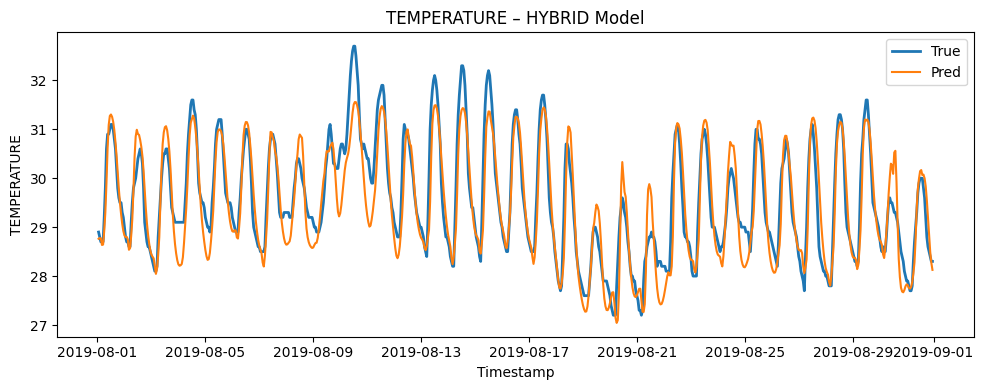

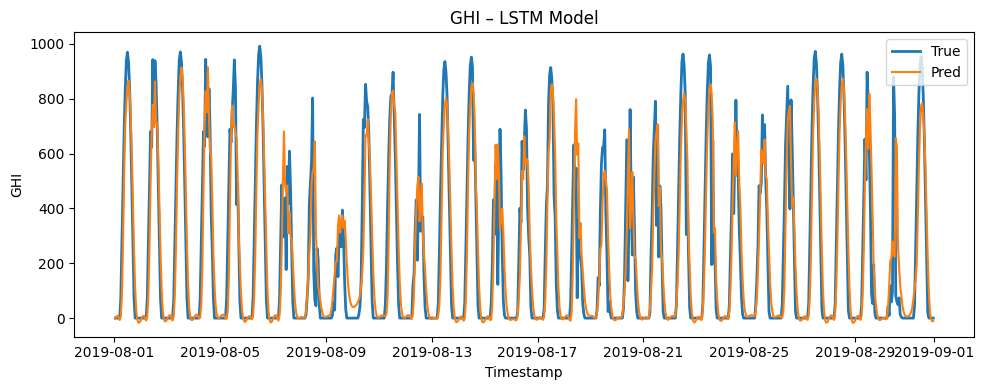

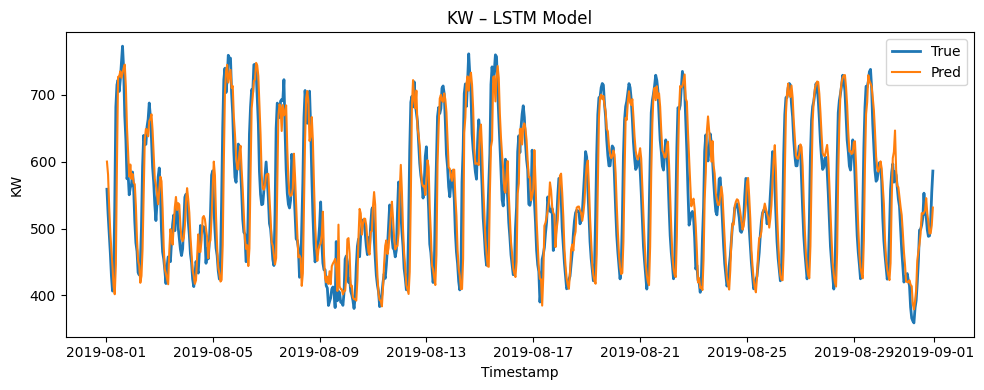

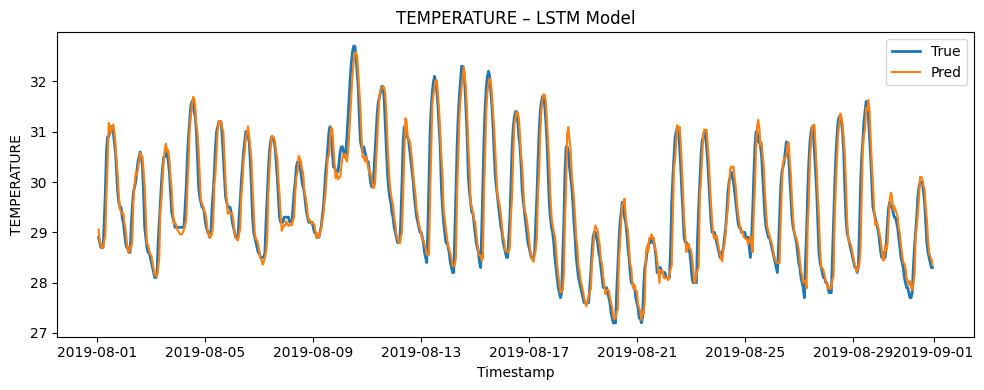

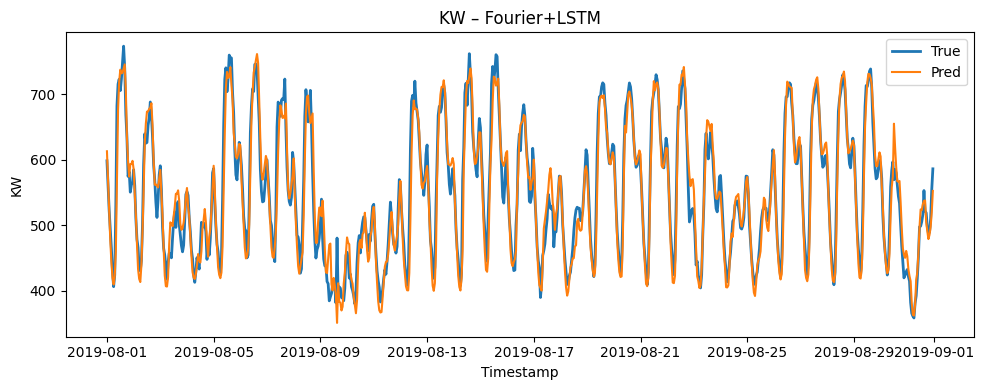

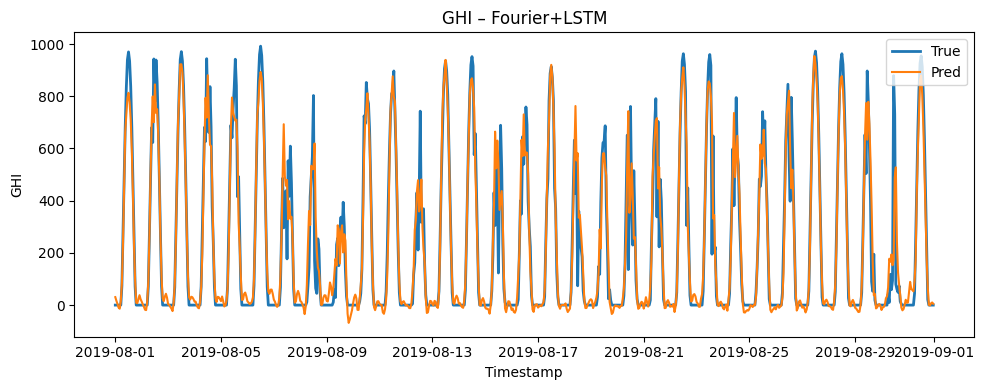

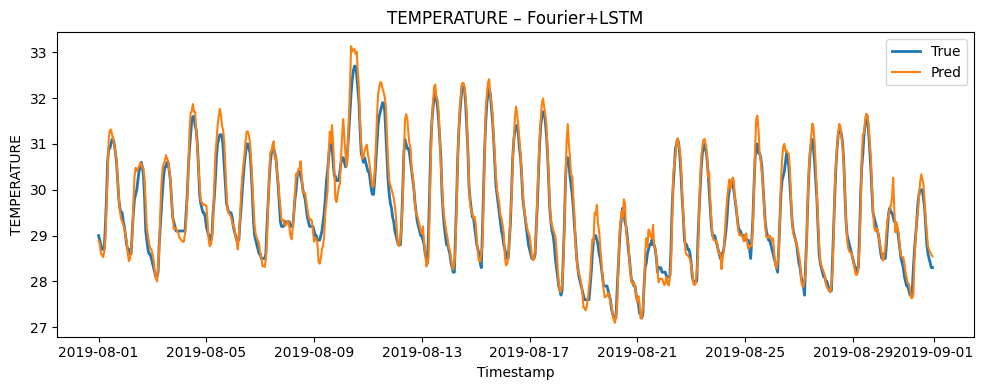

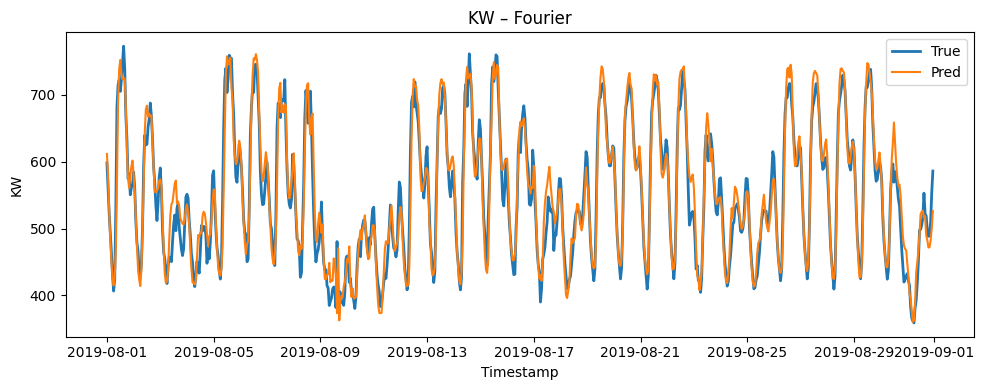

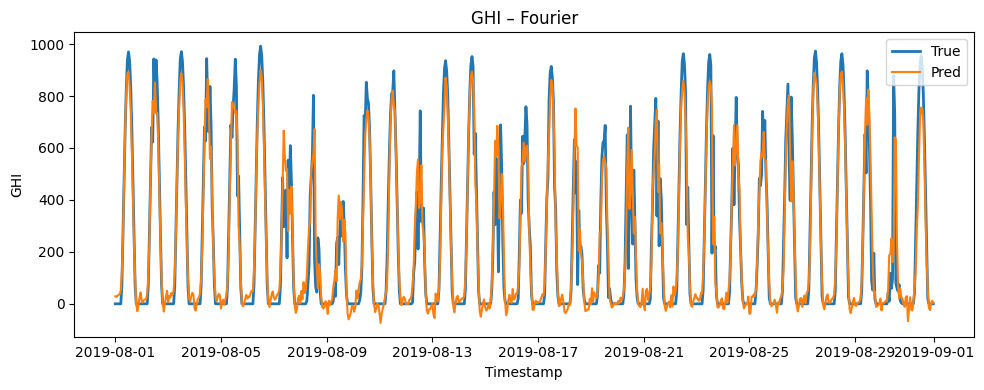

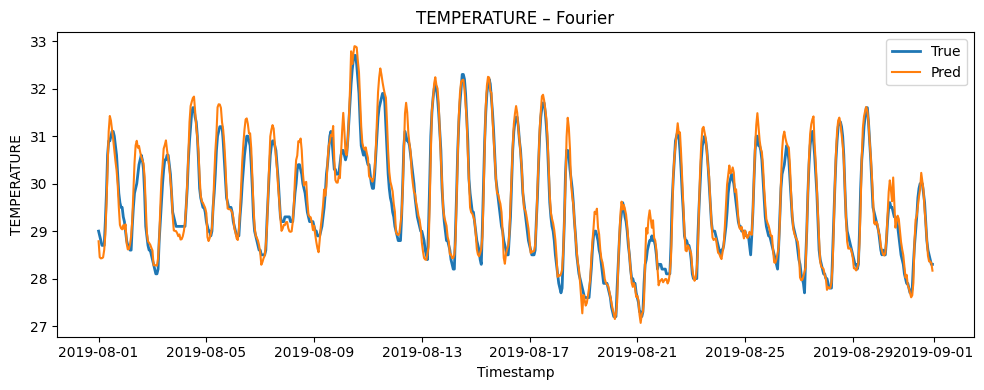

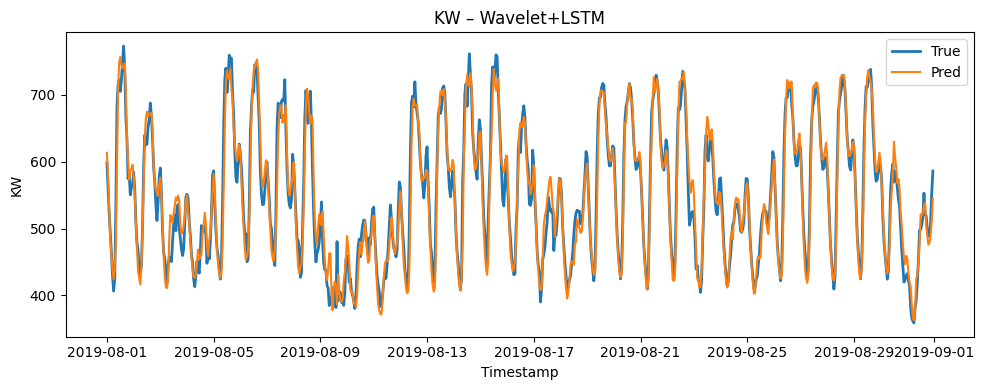

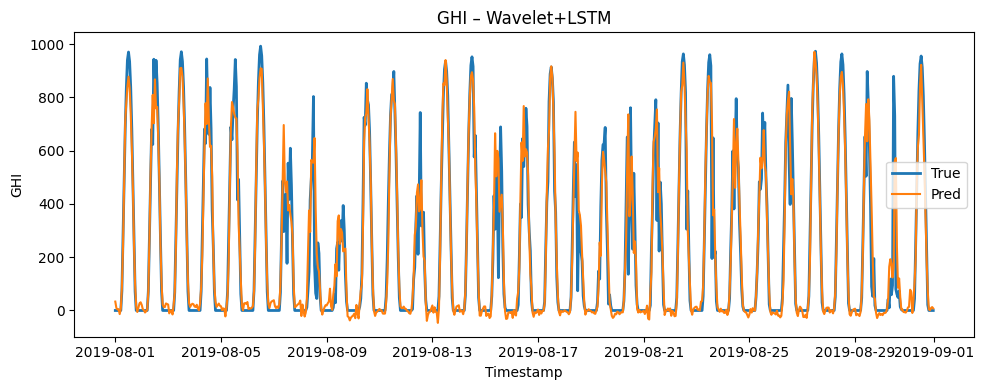

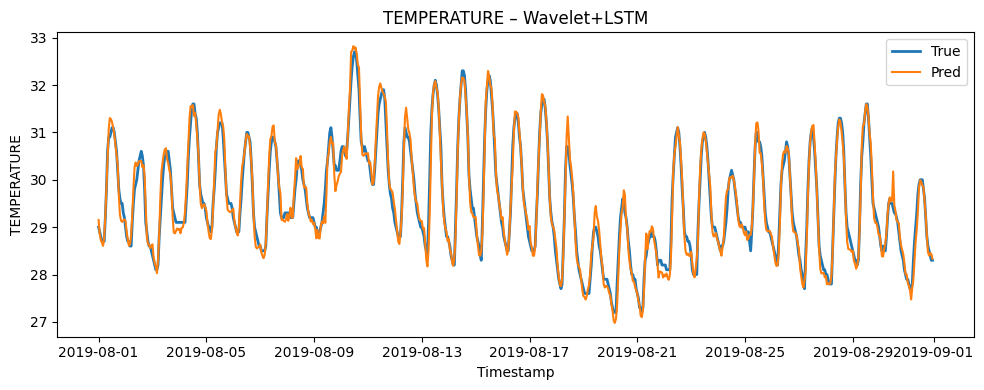

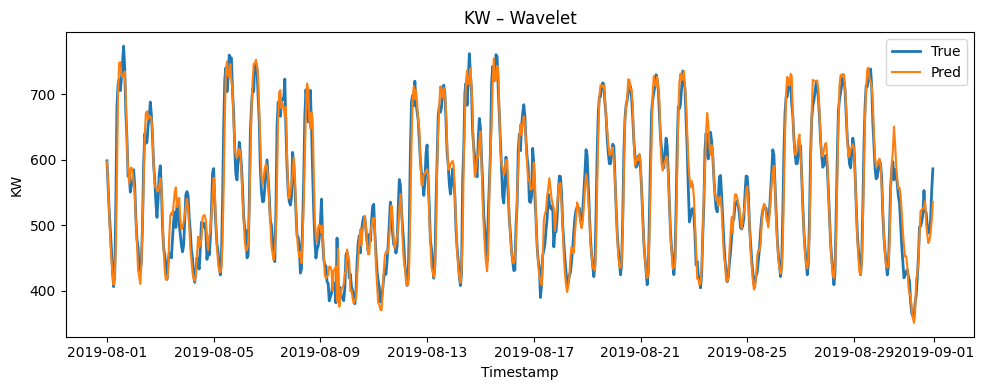

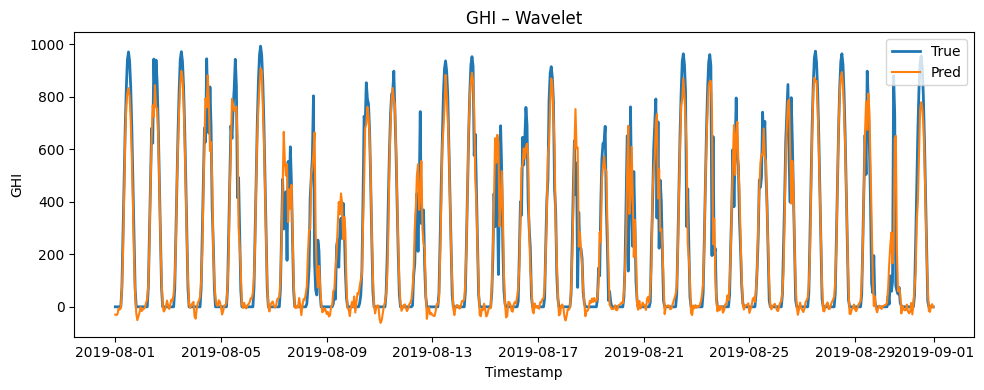

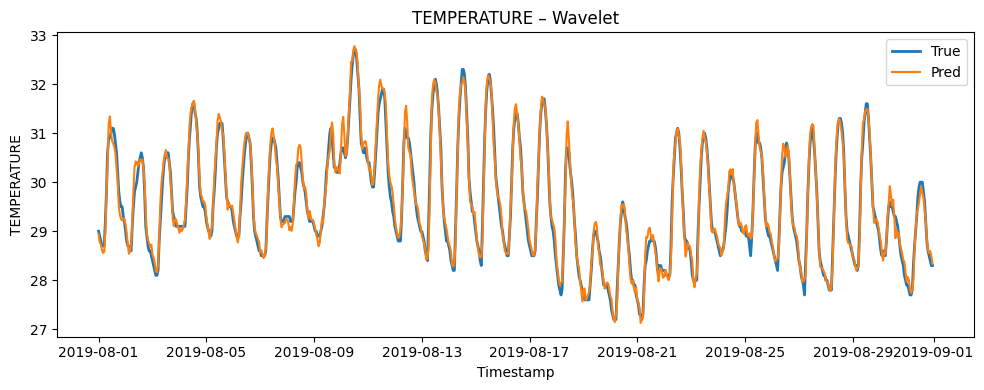

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Base directory where files live
base = Path("/Users/rr/Documents/Diajeng/TA/program/progress_ta/dataset/dataset_lstm_hybrid")

# Load true August data once
true_df = pd.read_csv(base / "dataset_agustus.csv", parse_dates=[["date", "time"]])
true_df.rename(columns={"date_time": "timestamp", 
                        "KW_TRUE": "KW", 
                        "TEMPERATURE_TRUE": "TEMPERATURE", 
                        "GHI_TRUE": "GHI"}, inplace=True)
true_df["timestamp"] = pd.to_datetime(true_df["timestamp"])

# Helper: plot and show
def plot_single(pred_ts, pred_val, true_ts, true_val, title, ylabel):
    plt.figure(figsize=(10,4))
    plt.plot(true_ts, true_val, label="True", linewidth=2)
    plt.plot(pred_ts, pred_val, label="Pred")
    plt.title(title)
    plt.xlabel("Timestamp")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------- Individual prediction CSVs -------------
pred_files = [
    "hybrid_pred_vs_true_kw_august.csv",
    "hybrid_pred_vs_true_ghi_august.csv",
    "hybrid_pred_vs_true_temperature_august.csv",
    "lstm_pred_vs_true_ghi_august.csv",
    "lstm_pred_vs_true_kw_august.csv",
    "lstm_vs_true_temperature_august.csv"
]

for fname in pred_files:
    path = base / fname
    if not path.exists():
        print(f"File not found: {path}")
        continue
    
    df_pred = pd.read_csv(path, parse_dates=["timestamp"])
    
    # Determine variable name by looking at columns
    pred_col = [c for c in df_pred.columns if c.endswith("_pred")][0]
    var = pred_col.split("_")[0]  # e.g., KW, GHI, TEMPERATURE
    
    pred_ts = df_pred["timestamp"]
    pred_val = df_pred[pred_col]
    
    # Align true values by timestamp
    true_series = true_df.set_index("timestamp")[var]
    true_val = true_series.reindex(pred_ts).values  # align index
    
    plot_single(pred_ts, pred_val, pred_ts, true_val,
                title=f"{var} – {fname.split('_')[0].upper()} Model",
                ylabel=var)

# ------------- MS (multi-series) CSVs ------------------
ms_files = {
    "Fourier+LSTM": "1hour_fourier_withlstm_MS.csv",
    "Fourier":      "1hour_fourier_withoutlstm_MS.csv",
    "Wavelet+LSTM": "1hour_wavelets_withlstm_MS.csv",
    "Wavelet":      "1hour_wavelets_withoutlstm_MS.csv"
}

for label, fname in ms_files.items():
    path = base / fname
    if not path.exists():
        print(f"File not found: {path}")
        continue
    
    df_ms = pd.read_csv(path, parse_dates=["datetime"])
    df_ms.rename(columns={"datetime": "timestamp", "temperature":"TEMPERATURE", "ghi":"GHI", "kw":"KW"}, inplace=True)
    
    for var in ["KW", "GHI", "TEMPERATURE"]:
        pred_ts = df_ms["timestamp"]
        pred_val = df_ms[var]
        
        # True values aligned
        true_series = true_df.set_index("timestamp")[var]
        true_val = true_series.reindex(pred_ts).values
        
        plot_single(pred_ts, pred_val, pred_ts, true_val,
                    title=f"{var} – {label}",
                    ylabel=var)
